In [690]:
import pandas as pd


mbc_parsimonious = pd.read_csv('tmp/test.csv', usecols=range(6), index_col=False)

mbc_parsimonious = mbc_parsimonious.fillna('')

mbc_parsimonious

,Document,Speaker,ID,Particles,Bases,Fragment
0,mbc001,Hemana Waaka,mbc001.6.0.1995-04-06,e.ngā/o.te,matawaka/motu,E ngā matawaka o te motu
1,mbc001,Hemana Waaka,mbc001.6.1.1995-04-06,kia/,ora/koutou,kia ora anō rā koutou katoa.
2,mbc001,Hemana Waaka,mbc001.6.2.1995-04-06,/ā/mō,anei/tātou/wehenga/tēnei/ata,Anei rā ā tātou wehenga kōrero mō tēnei ata.
3,mbc001,Hemana Waaka,mbc001.8.0.1995-04-06,/i.te/o.te/o.te/o/ki.te/i,mai/tīmatanga/kuhu/rōpū/pōhutu/marae/whakarewa...,Mai i te tīmatanga o te kuhu atu o Te Rōpū o P...
4,mbc001,Hemana Waaka,mbc001.8.1.1995-04-06,//a.ngā/i,tērā/anō/ētahi/āwangawanga/kaumātua/roto-rua,tērā anō ētahi āwangawanga a ngā kaumātua rā i...
...,...,...,...,...,...,...
192333,mbc273,Wena Tait,mbc273.128.15.1995-10-17,,whitu,whitu
192334,mbc273,Wena Tait,mbc273.128.16.1995-10-17,,rima,rima.
192335,mbc273,Wena Tait,mbc273.128.17.1995-10-17,nō,reira,Nō reira
192336,mbc273,Wena Tait,mbc273.128.18.1995-10-17,ko//e,wena/tēnei/mihi,ko Wena [Tait] tēnei e mihi atu nei


In [691]:
import numpy as np


df = pd.DataFrame(mbc_parsimonious)
for states in ['Particles', 'Bases']:
    df[states] = df[states].str.split('/')

df['Weight'] = np.log(df['Particles'].str.len())

df = df.sample(5000, weights=df['Weight'])
df

,Document,Speaker,ID,Particles,Bases,Fragment,Weight
24192,mbc059,Dan Hiramana-rua,mbc059.36.1.1995-09-07,"[he, ngā, kia, te, i.a, e, ki.ngā, me.te]","[whakangāwari, ture, taea, whakauru, ngāi, māt...",he whakangāwari kē ngā ture kia taea ai te wha...,2.079442
47240,mbc100,Hōne Apa-nui,mbc100.74.38,"[he, tā, he, i.te]","[mea, mātou, mahi, hāereere, whenua]",He mea nui tā mātou mahi he hāereere i te when...,1.386294
2704,mbc007,Richard Ngata,mbc007.89.5.1995-06-10,"[kia, ]","[uru, wēnā]",kia uru atu wēnā,0.693147
3569,mbc009,Hemana Waaka,mbc009.120.3.1995-07-11,"[o, , ko.te]","[tohu, rāua, whiti-o-rongo-mai]",o Tohu Kākahi rāua ko Te Whiti-o-Rongo-mai,1.098612
151245,mbc219,Lewis Moeau,mbc219.29.20.1996-08-04,"[i, e, i, te, ki]","[pānuitia, au, haere, minita, poihākena]",i pānuitia e au i haere te Minita ki Poihākena,1.609438
...,...,...,...,...,...,...,...
177481,mbc253,Whare-huia Milroy,mbc253.8.84,"[he, ]","[kura, tēnei]",he kura tēnei,0.693147
41620,mbc095,Helene Crown,mbc095.82.7,"[, ko.te]","[engari, mea]",Engari ko te mea nui,0.693147
119031,mbc177,Nancy Kururangi,mbc177.48.20,"[nā, ki.a]","[reira, koutou]",Nā reira ki a koutou katoa,0.693147
30590,mbc073,Wai-horoi Shortland,mbc073.83.2.1996-01-03,"[i, i.te, mō.te]","[runga, whakataukī, tētēkura]",i runga anō i te whakataukī mō te tētēkura,1.098612


Note: mode of base count is right shifted relative to mode of marker count, on weighted sample. We can investigate whether this is an effect of false starts, which would increase the ratio of marker-base, or of complex phrases, which would decrease it.

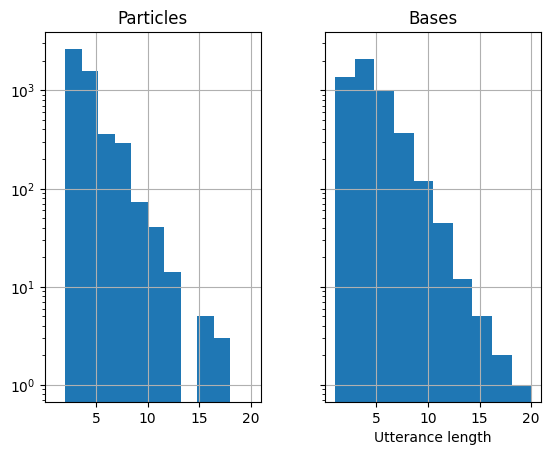

In [692]:
import matplotlib.pyplot as plt


chart = pd.DataFrame()
for states in ['Particles', 'Bases']:
    chart[states] = df[states].str.len()

chart.hist(sharex=True, sharey=True)
plt.xlabel('Utterance length')
plt.yscale('log')
plt.show()

In [693]:
import numpy as np


def get_observations(df: pd.DataFrame, col):
    observations = df[col].dropna().array
    lengths = np.array([len(i) for i in observations])
    return np.concatenate(observations), lengths

observations = pd.DataFrame([(col, *get_observations(df, col)) for col in ['Particles', 'Bases']], columns=['Series', 'Items', 'Lengths']).set_index('Series')
observations

,Items,Lengths
Series,,
Particles,"[he, ngā, kia, te, i.a, e, ki.ngā, me.te, he, ...","[8, 4, 2, 3, 5, 5, 3, 2, 9, 2, 3, 3, 4, 3, 4, ..."
Bases,"[whakangāwari, ture, taea, whakauru, ngāi, māt...","[8, 5, 2, 3, 5, 5, 3, 2, 10, 2, 3, 4, 4, 4, 4,..."


In [694]:
pd.DataFrame(observations.apply(lambda x: (len(x['Items']), len(pd.Series(x['Items']).unique()), pd.Series(x['Lengths']).mean()), axis=1).tolist(), columns=['Items', 'Unique', 'MeanLength'])

,Items,Unique,MeanLength
0,19148,158,3.8296
1,19692,2502,3.9384


In [695]:
observations['Items'].apply(lambda x: pd.Series(x).groupby(x).count().describe()).T

Series,Particles,Bases
count,158.000000,2502.000000
mean,121.189873,7.870504
std,342.893108,28.514691
min,1.000000,1.000000
25%,2.000000,1.000000
50%,7.000000,1.000000
75%,64.250000,4.000000
max,3021.000000,512.000000


/Users/connortaylorbrown/Desktop/linguistics/masters/thesis/mbc-analyser/venv/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)


array([ 4.76090445e+00,  1.97503366e-03, -9.80948205e-02])

tēnei             1.0
rātou             2.0
roto              3.0
tātou             4.0
kōrero            5.0
                ...  
huraina        1847.0
hura           1847.0
whakawhāiti    1847.0
whakaākina     1847.0
whakatāngia    1847.0
Length: 2502, dtype: float64

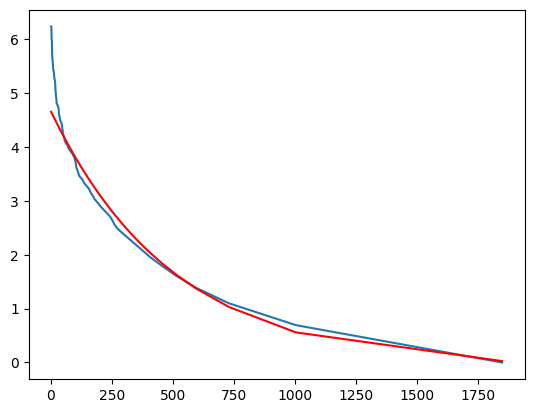

In [696]:
import numpy as np
from scipy.optimize import curve_fit


def rank(df: pd.DataFrame, col):
    items = df['Items'].T[col]
    return pd.Series(items).groupby(items).count().sort_values()


states = rank(observations, 'Bases')
log_freq = np.log(states)

def f(x, a, b, c):
    return a / np.exp(b * x) + c

order = log_freq.rank(ascending=False)
popt, _ = curve_fit(f, order, log_freq)

display(popt)
display(order.sort_values())
plt.plot(order, log_freq)
plt.plot(order, f(order, *popt), 'r-')
plt.show()

A substantial proportion of utterances contain hapaxes, when analysed by base.

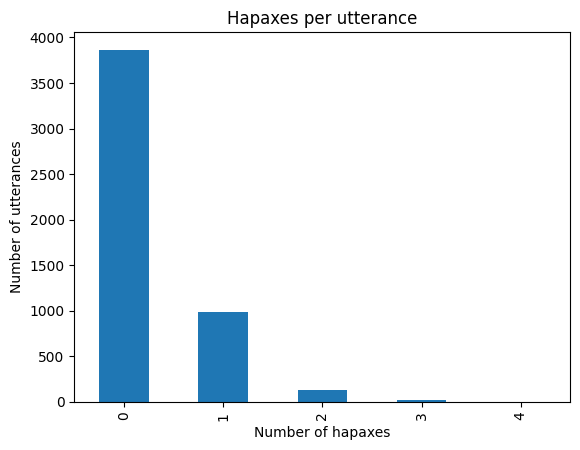

In [697]:
col = 'Bases'
freq = np.log(rank(observations, col))

hapaxes = df[col].apply(lambda x: sum(1 for i in x if not freq[i]))
hapaxes.groupby(hapaxes).count().plot.bar()
plt.title('Hapaxes per utterance')
plt.xlabel('Number of hapaxes')
plt.ylabel('Number of utterances')
plt.show()

In [698]:
def to_model(df, col, f):
    order = f(col)
    id_func = np.vectorize(lambda x: order[x])
    series = df.T[col]
    return tuple(x.reshape(-1, 1) for x in (id_func(series.T['Items']).astype(int), series.T['Lengths']))


to_model(observations, 'Particles', lambda col: rank(observations, col))

(array([[ 549],
        [ 646],
        [ 368],
        ...,
        [  65],
        [1733],
        [  49]], shape=(19148, 1)),
 array([[8],
        [4],
        [2],
        ...,
        [2],
        [3],
        [3]], shape=(5000, 1)))

In [699]:
from hmmlearn.hmm import CategoricalHMM
from sklearn.utils import check_random_state


def score(model: CategoricalHMM, *to_model):
    return (f(*to_model) for f in (model.score, model.aic, model.bic))


class Fitter:
    def __init__(self, *to_model, **kwargs):
        self.to_model = to_model
        self.kwargs = kwargs

    def score(self):
        return [score(x, *self.to_model) for x in self._monitor]

    def fit(self, n, trials):
        models = [CategoricalHMM(n, **self.kwargs) for _ in range(trials)]
        self._monitor = [model.fit(*self.to_model) for model in models]
        return min(models, key=lambda x: x.score(*self.to_model))

rs = check_random_state(57)

Scoring for more complex models of first-order phrase marking behaviour is linearly worse (over AIC, BIC, LL), so a two-state model is selected.

In [700]:
fitter = Fitter(*to_model(observations, 'Particles', lambda col: rank(observations, col)), n_iter=1000, random_state=rs)
particles = fitter.fit(2, 10)

particles

,n_components,2
,startprob_prior,1.0
,transmat_prior,1.0
,emissionprob_prior,1.0
,n_features,np.int64(3022)
,algorithm,'viterbi'
,random_state,RandomState(M...at 0x17FC71240
,n_iter,1000
,tol,0.01
,verbose,False
,params,'ste'


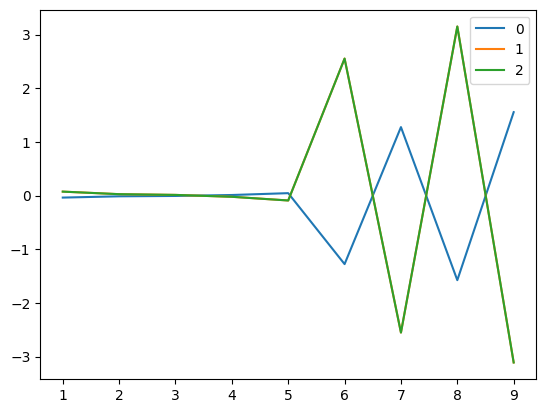

In [701]:
scores = pd.DataFrame(fitter.score())
scores = scores.diff()

scores.plot()
plt.show()

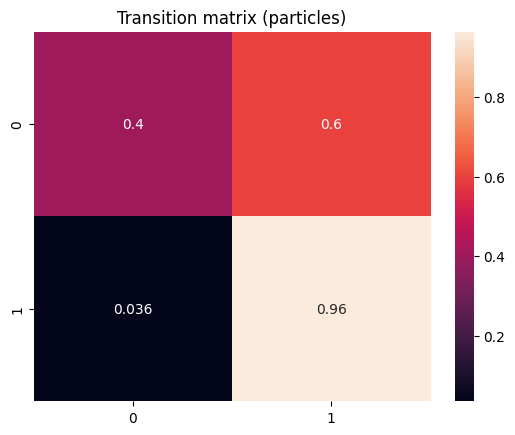

In [702]:
import seaborn as sns


sns.heatmap(particles.transmat_, annot=True)
plt.title('Transition matrix (particles)')
plt.show()

Bases models take significantly longer to fit than marker models, and seem amenable to an additional hidden state. Training time is likely due to a substantial incidence of hapaxes.

In [703]:
fitter = Fitter(*to_model(observations, 'Bases', lambda col: rank(observations, col)), n_iter=1000, random_state=rs)
base_models = [fitter.fit(n, 10) for n in [2, 3, 4]]

base_models

[CategoricalHMM(n_components=2, n_features=np.int64(513), n_iter=1000,
                random_state=RandomState(MT19937) at 0x17FC71240),
 CategoricalHMM(n_components=3, n_features=np.int64(513), n_iter=1000,
                random_state=RandomState(MT19937) at 0x17FC71240),
 CategoricalHMM(n_components=4, n_features=np.int64(513), n_iter=1000,
                random_state=RandomState(MT19937) at 0x17FC71240)]

<Axes: >

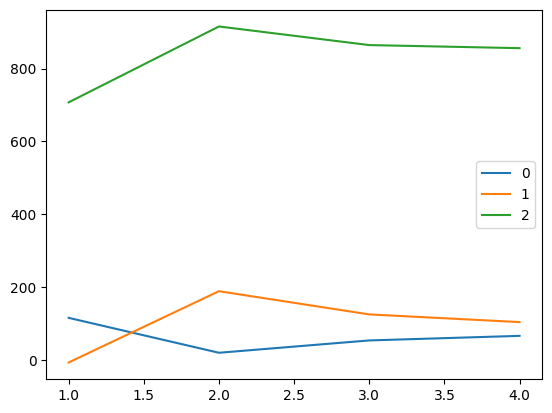

In [ ]:
pd.DataFrame([score(model, *fitter.to_model) for model in base_models]).diff().plot()

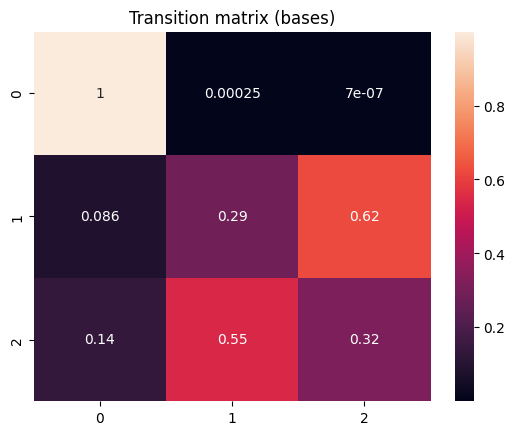

In [ ]:
import seaborn as sns


bases = min(base_models, key=lambda x: x.aic(*fitter.to_model))
sns.heatmap(bases.transmat_, annot=True)
plt.title('Transition matrix (bases)')
plt.show()

In [643]:
ex = pd.DataFrame(df[['ID', 'Particles', 'Bases', 'Fragment']])
ex

,ID,Particles,Bases,Fragment
82094,mbc139.126.25,"[ka, , ki, te]","[taea, koe]",ka taea koe ki te
83295,mbc141.56.25,"[mā, hei, i.te]","[rātou, kōrero, tuatahi]",mā rātou anō hei kōrero i te tuatahi.
106422,mbc163.871.6,"[i, , ki.a]","[kōrero, au, [joe]",i kōrero au ki a [Joe Hawke] inanahi nei
119775,mbc178.141.3,"[kua, ]","[kōrero, au]",kua kōrero atu au.
155697,mbc226.188.1.1995-11-12,"[ko, tā, i, i.te, e, ki.a]","[tēwhea, u, roto, reo, tino, koe]",ko tēwhea tāu waiata i roto i te reo Māori e t...
...,...,...,...,...
32555,mbc078.45.4.1995-03-15,"[, te, ki.ngā]","[nui, aroha, moni]",Nui kē te aroha ki ngā moni nā
174733,mbc249.20.123.1995-08-20,"[ko.te, ki, te]",[mōhio],ko te mōhio ki te
55678,mbc109.110.0,"[, ngā, i, e, i]","[nui, mahi, mahia, ia, koneki]",Nui tonu ngā mahi i mahia e ia i koneki.
135191,mbc196.10.32,"[, i.a]","[roto, tāua]",roto tonu i a tāua


In [644]:
def predict(model: CategoricalHMM, df: pd.DataFrame, col, f):
    order = f(col)
    id_func = np.vectorize(lambda x: order[x])
    return df.apply(lambda x: model.predict(id_func(x[col]).astype(int).reshape(1, -1)).tolist(), axis=1)

modelled = pd.DataFrame(ex[['ID', 'Fragment']])
modelled['Particles'] = predict(particles, ex, 'Particles', lambda col: rank(observations, col))
modelled['Bases'] = predict(bases, ex, 'Bases', lambda col: rank(observations, col))

modelled

,ID,Fragment,Particles,Bases
82094,mbc139.126.25,ka taea koe ki te,"[1, 1, 1, 0]","[2, 1]"
83295,mbc141.56.25,mā rātou anō hei kōrero i te tuatahi.,"[1, 1, 0]","[2, 1, 2]"
106422,mbc163.871.6,i kōrero au ki a [Joe Hawke] inanahi nei,"[1, 1, 0]","[2, 1, 2]"
119775,mbc178.141.3,kua kōrero atu au.,"[1, 0]","[2, 1]"
155697,mbc226.188.1.1995-11-12,ko tēwhea tāu waiata i roto i te reo Māori e t...,"[1, 1, 1, 1, 1, 0]","[2, 1, 2, 1, 2, 1]"
...,...,...,...,...
32555,mbc078.45.4.1995-03-15,Nui kē te aroha ki ngā moni nā,"[1, 1, 0]","[2, 1, 2]"
174733,mbc249.20.123.1995-08-20,ko te mōhio ki te,"[1, 1, 0]",[2]
55678,mbc109.110.0,Nui tonu ngā mahi i mahia e ia i koneki.,"[1, 1, 1, 1, 0]","[0, 0, 0, 0, 0]"
135191,mbc196.10.32,roto tonu i a tāua,"[1, 0]","[2, 2]"


In [645]:
printable = pd.DataFrame(modelled)
for col in ['Particles', 'Bases']:
    printable[col] = printable[col].apply(lambda x: '-'.join(str(i) for i in x))

printable[['ID', 'Particles', 'Bases', 'Fragment']]

,ID,Particles,Bases,Fragment
82094,mbc139.126.25,1-1-1-0,2-1,ka taea koe ki te
83295,mbc141.56.25,1-1-0,2-1-2,mā rātou anō hei kōrero i te tuatahi.
106422,mbc163.871.6,1-1-0,2-1-2,i kōrero au ki a [Joe Hawke] inanahi nei
119775,mbc178.141.3,1-0,2-1,kua kōrero atu au.
155697,mbc226.188.1.1995-11-12,1-1-1-1-1-0,2-1-2-1-2-1,ko tēwhea tāu waiata i roto i te reo Māori e t...
...,...,...,...,...
32555,mbc078.45.4.1995-03-15,1-1-0,2-1-2,Nui kē te aroha ki ngā moni nā
174733,mbc249.20.123.1995-08-20,1-1-0,2,ko te mōhio ki te
55678,mbc109.110.0,1-1-1-1-0,0-0-0-0-0,Nui tonu ngā mahi i mahia e ia i koneki.
135191,mbc196.10.32,1-0,2-2,roto tonu i a tāua


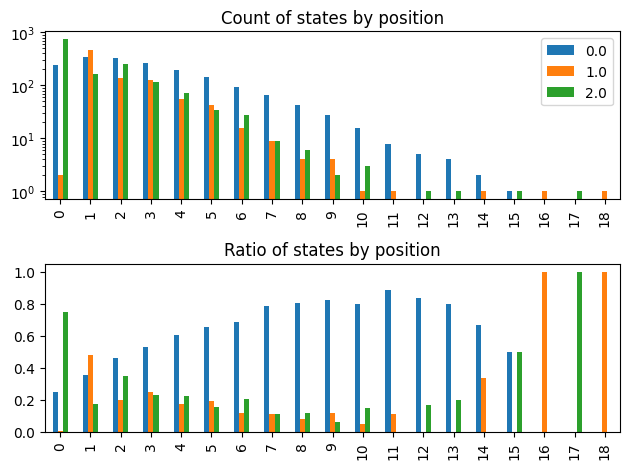

In [646]:
by_position = pd.DataFrame(modelled['Bases'].tolist()).apply(lambda x: x.value_counts(), axis=0)


fig, ax = plt.subplots(2)
ax[0].set_title('Count of states by position')
by_position.T.plot.bar(ax=ax[0])
ax[0].set_yscale('log')

ax[1].set_title('Ratio of states by position')
(by_position / by_position.sum()).T.plot.bar(ax=ax[1])
ax[1].get_legend().remove()

plt.tight_layout()

In [501]:
def find(df: pd.DataFrame, model: str, state):
    return df[model].apply(lambda x: state in x)


modelled.sort_values('Particles', ascending=False, key=lambda x: x.str.len())
modelled\
    .loc[find(ex, 'Particles', 'nā.te') & find(ex, 'Particles', 'i')]
    # .loc[modelled['Particles'].str.len() <= 4]\

,ID,Fragment,Particles,Bases
151911,mbc220.25.13.1995-04-09,ko ētehi āhuatanga ko te mōhio iho nā te kaitu...,"[1, 0, 1, 0, 0]","[2, 2, 2, 3, 1, 0]"
101710,mbc159.73.40,Nā te wairua ērā mea i whāngai ki a ia.,"[1, 0, 2, 2]","[1, 0, 3, 1, 0]"


In [502]:
def tag(col):
    total = {}
    for keys, states in zip(ex[col], modelled[col]):
        for k, state in zip(keys, states):
            states = total.get(k)
            if not states:
                states = {}
                total[k] = states
            
            c = states.get(state)
            if not c:
                states[state] = 0
            
            states[state] += 1
    
    return total
        

states = pd.DataFrame.from_dict(tag('Bases')).T
states

,1,3,0,2
konā,3.0,1.0,NaN,NaN
au,NaN,2.0,47.0,2.0
whakatūtū,NaN,1.0,NaN,NaN
na,14.0,NaN,7.0,3.0
toa,2.0,2.0,1.0,NaN
...,...,...,...,...
nuhaka,1.0,NaN,NaN,NaN
pītau,1.0,NaN,NaN,NaN
kete,1.0,NaN,NaN,NaN
rawe,NaN,NaN,NaN,1.0


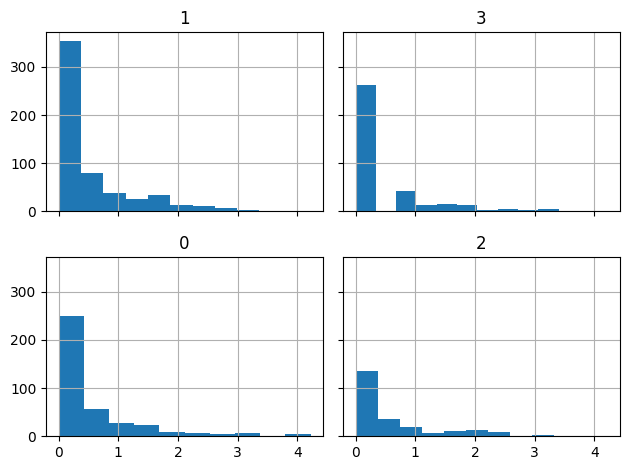

In [503]:
np.log(states).hist(sharex=True, sharey=True)
plt.tight_layout()

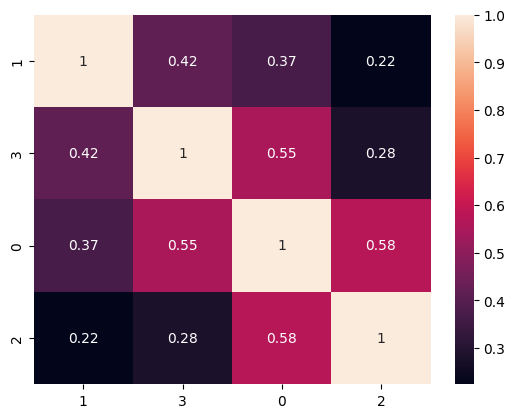

In [504]:
import seaborn as sns


sns.heatmap(states.corr(), annot=True)
plt.show()

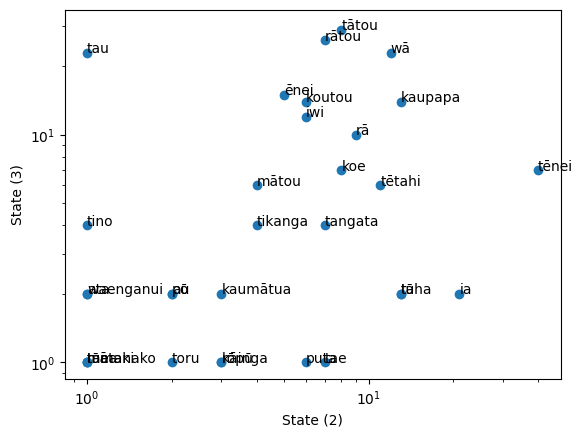

In [505]:
def annotate(df: pd.DataFrame, x, y):
    for i, row in df.iterrows():
        plt.annotate(i, (row[x], row[y]))


filtered = states.sample(100, weights=states.sum(axis=1)).fillna(0)

x = 2
y = 3

plt.scatter(x=filtered[x], y=filtered[y])
annotate(filtered, x, y)

plt.xlabel(f'State ({x})')
plt.ylabel(f'State ({y})')
plt.xscale('log')
plt.yscale('log')
plt.show()

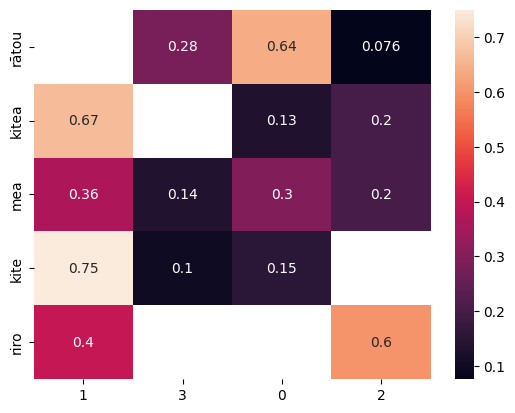

In [506]:
ratio = states.div(states.sum(axis=1), axis=0)
# filtered = ratio
filtered = ratio.loc[ratio.index.isin(['riro','rātou','mea','kitea','kite'])]

sns.heatmap(filtered, annot=True)
plt.show()

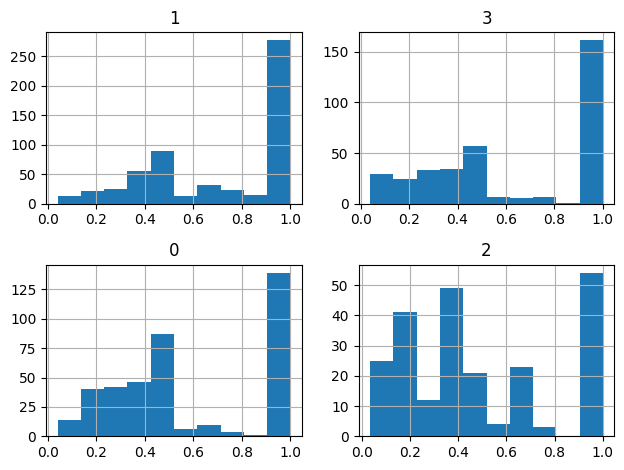

In [507]:
ratio.hist()
plt.tight_layout()

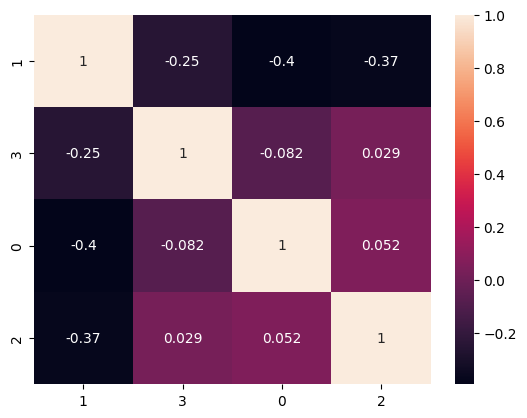

In [508]:
sns.heatmap(ratio.corr(), annot=True)
plt.show()

In [509]:
summary = pd.DataFrame(ratio)
summary['Weight'] = states.sum(axis=1)
sv = pd.read_csv('input/sv.txt', header=None).set_index(0)
summary['Stative'] = summary.index.isin(sv.index)

summary.reset_index()

,index,1,3,0,2,Weight,Stative
0,konā,0.750000,0.250000,NaN,NaN,4.0,False
1,au,NaN,0.039216,0.921569,0.039216,51.0,False
2,whakatūtū,NaN,1.000000,NaN,NaN,1.0,False
3,na,0.583333,NaN,0.291667,0.125000,24.0,False
4,toa,0.400000,0.400000,0.200000,NaN,5.0,False
...,...,...,...,...,...,...,...
985,nuhaka,1.000000,NaN,NaN,NaN,1.0,False
986,pītau,1.000000,NaN,NaN,NaN,1.0,False
987,kete,1.000000,NaN,NaN,NaN,1.0,False
988,rawe,NaN,NaN,NaN,1.000000,1.0,False


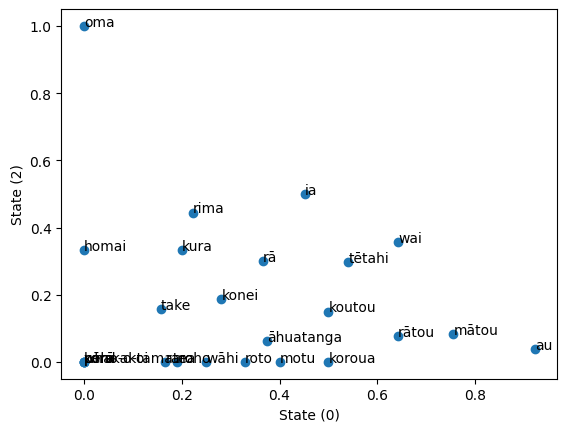

In [510]:
x = 0
y = 2

filtered = ratio.sample(25, weights=states.sum(axis=1)).fillna(0)
plt.scatter(x=filtered[x], y=filtered[y])
annotate(filtered, x, y)
plt.xlabel(f'State ({x})')
plt.ylabel(f'State ({y})')
plt.show()

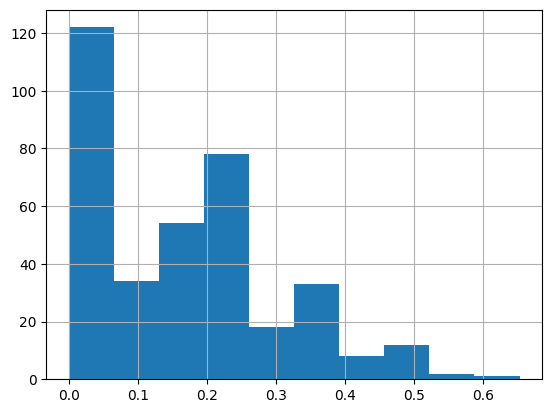

In [511]:
sd = states.div(states.sum(axis=1), axis=0).std(axis=1)
sd.hist()
plt.show()

np.float64(0.5017888257089462)

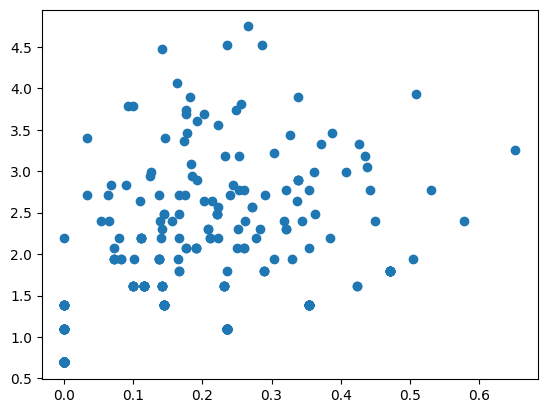

In [512]:
log_count = np.log(states.sum(axis=1))
display(sd.corr(log_count))
plt.scatter(x=sd, y=log_count)
plt.show()